# Myntra Sales Prediction

**Project:** Predicting Product Demand (Sales Proxy) for Myntra Fashion Products using Machine Learning

**Author:** Sagar Baghel

**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship Program (BharatCares x AICTE)

---

### Problem Statement
Myntra is one of India's largest online fashion retailers. Predicting how well a product will sell helps the business with inventory planning, pricing strategy, and marketing focus. This project builds a Machine Learning pipeline that analyzes a real-world, web-scraped Myntra product dataset (jeans/pants category) and predicts a **sales/demand proxy** for a product based on its price, discount, brand, rating and product attributes.

### About the Dataset
The dataset was collected via web scraping of Myntra's men's jeans/pants listings and contains the following columns:

| Column | Description |
|---|---|
| `brand_name` | Brand of the product |
| `pants_description` | Product title (contains fit, rise, fabric info) |
| `price` | Selling price (INR) |
| `MRP` | Maximum Retail Price (INR) |
| `discount_percent` | Discount offered |
| `ratings` | Average customer rating (1-5) |
| `number_of_ratings` | Number of customers who rated the product |

**Important note on the target variable:** The raw dataset does not contain an explicit "units sold" column (Myntra does not publish this publicly). Following common practice in e-commerce analytics projects, we use **`number_of_ratings` as a proxy for sales/demand** — a product that more customers have rated has, in general, sold to more customers. We predict this proxy and refer to the task as *Sales Prediction* throughout this notebook.


In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42


## 2. Load the Dataset

In [2]:
df = pd.read_csv('myntra_dataset_ByScraping.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (52120, 7)


,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  str    
 1   pants_description  52120 non-null  str    
 2   price              52120 non-null  float64
 3   MRP                52120 non-null  float64
 4   discount_percent   52120 non-null  float64
 5   ratings            52120 non-null  float64
 6   number_of_ratings  52120 non-null  float64
dtypes: float64(5), str(2)
memory usage: 2.8 MB


In [4]:
df.describe()


,price,MRP,discount_percent,ratings,number_of_ratings
count,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000
mean,1594.515445,3180.398438,1.648256,3.997794,91.568937
std,1495.972325,2201.883218,4.687529,0.420404,433.918513
min,337.000000,499.000000,0.020000,1.000000,5.000000
25%,989.000000,2499.000000,0.400000,3.800000,16.000000
50%,1439.000000,2999.000000,0.500000,4.000000,35.000000
75%,1829.000000,3499.000000,0.630000,4.200000,74.000000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000


## 3. Data Cleaning

We check for missing values, duplicate rows, and inconsistent values before proceeding.


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
dtype: int64

Duplicate rows: 17047


In [6]:
# Remove exact duplicate rows (same product scraped more than once)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (35073, 7)


In [7]:
# The 'discount_percent' column is expected to be a fraction between 0 and 1
# (e.g. 0.45 = 45% off). A scraping inconsistency has left some rows with
# whole-number percentages (e.g. 64 instead of 0.64). We standardise these.
print("Discount values greater than 1 (i.e. not a fraction):", (df['discount_percent'] > 1).sum())

df.loc[df['discount_percent'] > 1, 'discount_percent'] = df.loc[df['discount_percent'] > 1, 'discount_percent'] / 100

# Safety clip in case any values are still out of the expected [0, 1] range
df['discount_percent'] = df['discount_percent'].clip(0, 1)
print(df['discount_percent'].describe())


Discount values greater than 1 (i.e. not a fraction): 3546
count    35073.000000
mean         0.468419
std          0.184036
min          0.011000
25%          0.380000
50%          0.500000
75%          0.600000
max          1.000000
Name: discount_percent, dtype: float64


In [8]:
# Sanity check: price should never exceed MRP. Flag/drop such inconsistent rows.
bad_rows = (df['price'] > df['MRP']).sum()
print("Rows where price > MRP:", bad_rows)
df = df[df['price'] <= df['MRP']].reset_index(drop=True)
print("Final shape after cleaning:", df.shape)


Rows where price > MRP: 0
Final shape after cleaning: (35073, 7)


## 4. Feature Engineering

The `pants_description` field is a short free-text title (e.g. *"Men Slim Fit Mid-Rise Jeans"*). We extract useful categorical attributes from it: **fit type** and **rise type**. We also engineer a `discount_amount` (INR saved) feature.


In [9]:
def extract_fit(text):
    text = str(text).lower()
    fits = ['skinny', 'slim', 'straight', 'bootcut', 'boot cut', 'relaxed', 'regular',
            'loose', 'wide leg', 'tapered', 'jogger', 'cargo', 'anti fit', 'baggy', 'super skinny']
    for f in fits:
        if f in text:
            return f.title()
    return 'Other'

def extract_rise(text):
    text = str(text).lower()
    if 'low-rise' in text or 'low rise' in text:
        return 'Low-Rise'
    if 'mid-rise' in text or 'mid rise' in text:
        return 'Mid-Rise'
    if 'high-rise' in text or 'high rise' in text:
        return 'High-Rise'
    return 'Not Specified'

df['fit_type'] = df['pants_description'].apply(extract_fit)
df['rise_type'] = df['pants_description'].apply(extract_rise)
df['discount_amount'] = df['MRP'] - df['price']

df[['pants_description', 'fit_type', 'rise_type', 'discount_amount']].head(10)


,pants_description,fit_type,rise_type,discount_amount
0,Men Loose Fit Cotton Jeans,Loose,Not Specified,1125.0
1,Men Slim Fit Jeans,Slim,Not Specified,1170.0
2,Men Pure Cotton Jeans,Other,Not Specified,1525.0
3,Relaxed Fit Denim Jeans,Relaxed,Not Specified,1426.0
4,Men 511 Slim Fit Jeans,Slim,Not Specified,1421.0
5,Men Stretchable Jeans,Other,Not Specified,901.0
6,Men Relaxed Fit Jeans,Relaxed,Not Specified,1155.0
7,Men Anti Fit Jeans,Anti Fit,Not Specified,1176.0
8,Men Wide Leg Heavy Fade Jeans,Wide Leg,Not Specified,1960.0
9,Relaxed Fit Denim Jeans,Relaxed,Not Specified,1426.0


In [10]:
# Keep only brands with a reasonable number of listings; group rare brands as 'Other'
# to avoid an explosion of one-hot columns and overfitting on rare categories.
brand_counts = df['brand_name'].value_counts()
top_brands = brand_counts[brand_counts >= 50].index
df['brand_grouped'] = df['brand_name'].where(df['brand_name'].isin(top_brands), 'Other')
print("Number of brand categories used:", df['brand_grouped'].nunique())


Number of brand categories used: 114


## 5. Exploratory Data Analysis (EDA)

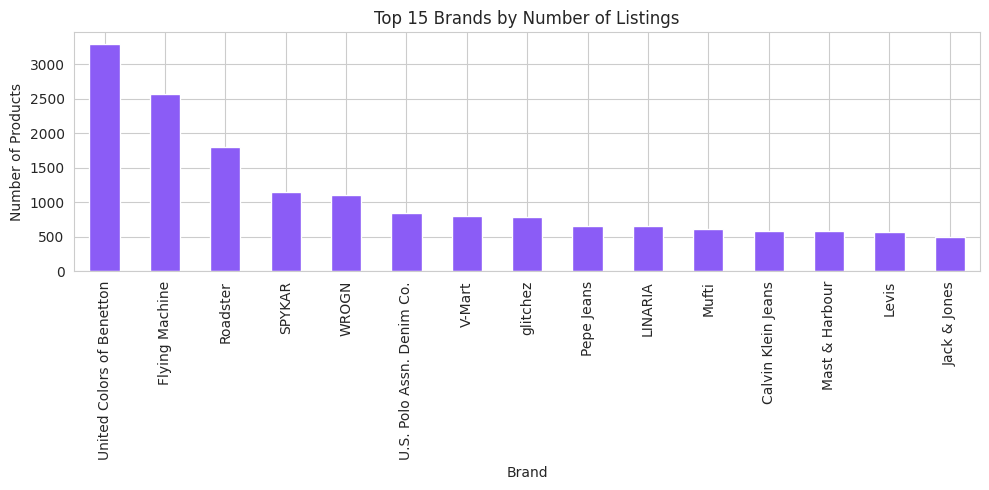

In [11]:
plt.figure(figsize=(10,5))
df['brand_name'].value_counts().head(15).plot(kind='bar', color='#8B5CF6')
plt.title('Top 15 Brands by Number of Listings')
plt.ylabel('Number of Products')
plt.xlabel('Brand')
plt.tight_layout()
plt.savefig('fig_top_brands.png', dpi=110)
plt.show()


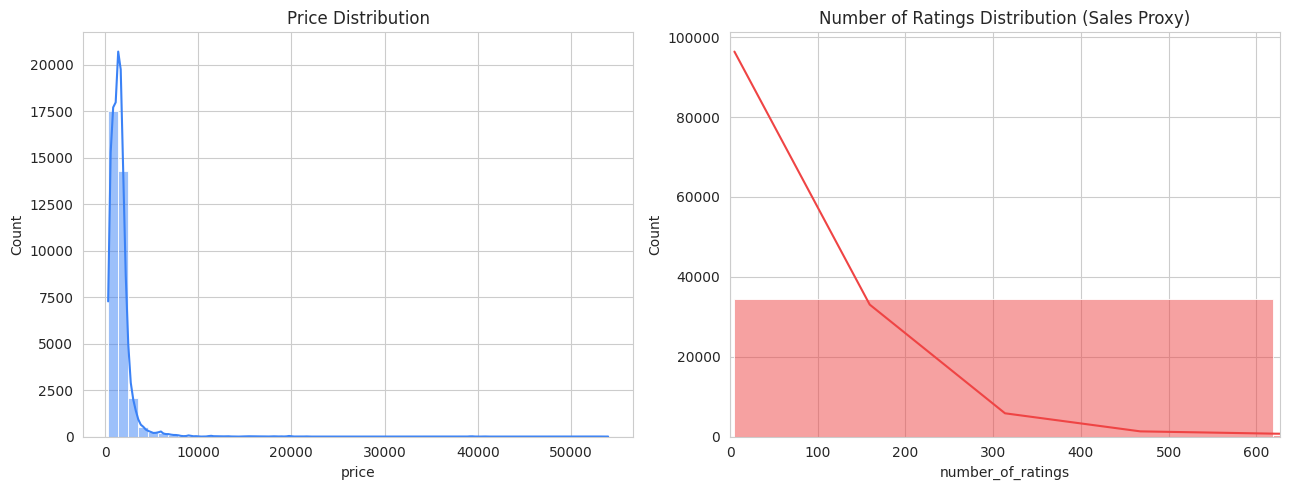

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='#3B82F6')
axes[0].set_title('Price Distribution')
sns.histplot(df['number_of_ratings'], bins=50, kde=True, ax=axes[1], color='#EF4444')
axes[1].set_title('Number of Ratings Distribution (Sales Proxy)')
axes[1].set_xlim(0, df['number_of_ratings'].quantile(0.98))
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=110)
plt.show()


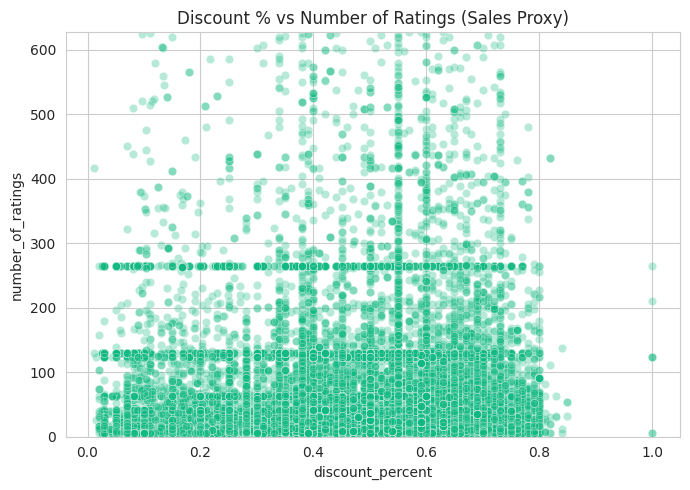

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='discount_percent', y='number_of_ratings', alpha=0.3, color='#10B981')
plt.ylim(0, df['number_of_ratings'].quantile(0.98))
plt.title('Discount % vs Number of Ratings (Sales Proxy)')
plt.tight_layout()
plt.savefig('fig_discount_vs_ratings.png', dpi=110)
plt.show()


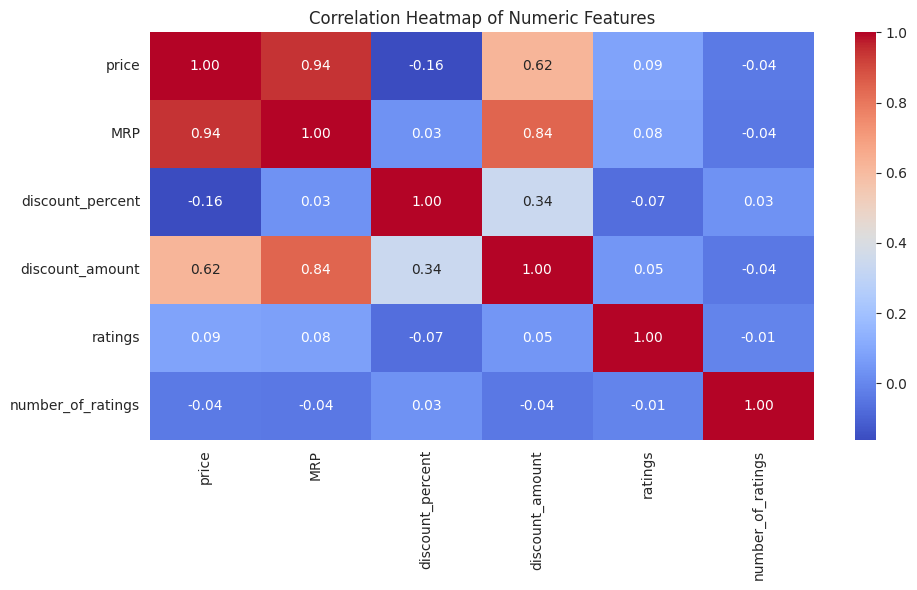

In [14]:
plt.figure(figsize=(10,6))
corr = df[['price','MRP','discount_percent','discount_amount','ratings','number_of_ratings']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=110)
plt.show()


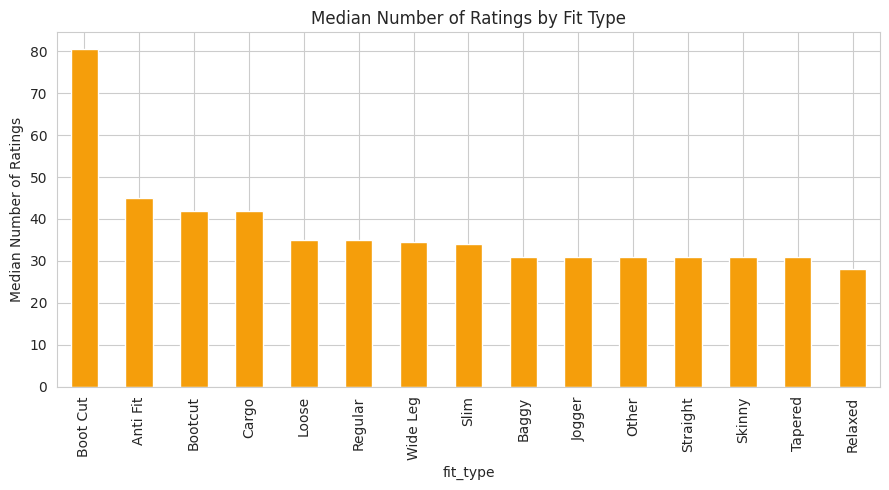

In [15]:
plt.figure(figsize=(9,5))
df.groupby('fit_type')['number_of_ratings'].median().sort_values(ascending=False).plot(kind='bar', color='#F59E0B')
plt.title('Median Number of Ratings by Fit Type')
plt.ylabel('Median Number of Ratings')
plt.tight_layout()
plt.savefig('fig_fit_type.png', dpi=110)
plt.show()


**Observations from EDA:**
- Product listings are dominated by a handful of major brands (WROGN, Flying Machine, United Colors of Benetton, Roadster, Mufti, Levi's).
- Both `price` and `number_of_ratings` are right-skewed — most products are moderately priced with relatively few ratings, while a small number of best-sellers have very high rating counts.
- `discount_percent` shows a weak-to-moderate relationship with `number_of_ratings`, suggesting heavier discounts are associated with (but do not strictly guarantee) higher sales volume.
- `price` and `MRP` are, as expected, strongly positively correlated.
- Certain fit types (e.g. Slim, Skinny, Straight) tend to have higher median rating counts, reflecting popular fashion trends.


## 6. Preprocessing for Modeling

Because `number_of_ratings` is heavily right-skewed, we predict `log1p(number_of_ratings)` and convert predictions back with `expm1` for evaluation on the original scale. This is standard practice for count-like, skewed targets.


In [16]:
features_num = ['price', 'MRP', 'discount_percent', 'discount_amount', 'ratings']
features_cat = ['brand_grouped', 'fit_type', 'rise_type']

X = df[features_num + features_cat].copy()
y = np.log1p(df['number_of_ratings'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (28058, 8)  Test shape: (7015, 8)


In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])


## 7. Model Building

We train and compare three regression models:
1. **Linear Regression** — simple baseline
2. **Random Forest Regressor** — captures non-linear relationships
3. **Gradient Boosting Regressor** — often the strongest tabular-data performer


In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds_log = pipe.predict(X_test)

    # Convert back to original scale for interpretable metrics
    y_test_orig = np.expm1(y_test)
    preds_orig = np.expm1(preds_log)

    mae = mean_absolute_error(y_test_orig, preds_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, preds_orig))
    r2 = r2_score(y_test, preds_log)  # R2 computed on log scale (model's fitting target)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 (log-scale)': r2})
    print(f"{name}: MAE={mae:.2f}  RMSE={rmse:.2f}  R2(log)={r2:.3f}")

results_df = pd.DataFrame(results).sort_values('R2 (log-scale)', ascending=False)
results_df


Linear Regression: MAE=89.16  RMSE=606.01  R2(log)=0.096


Random Forest: MAE=78.60  RMSE=581.52  R2(log)=0.400


Gradient Boosting: MAE=82.48  RMSE=597.57  R2(log)=0.365


,Model,MAE,RMSE,R2 (log-scale)
1,Random Forest,78.604033,581.523425,0.400255
2,Gradient Boosting,82.476626,597.573406,0.364904
0,Linear Regression,89.164333,606.010482,0.096204


/tmp/ipykernel_154/2481386393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 (log-scale)', palette='viridis')


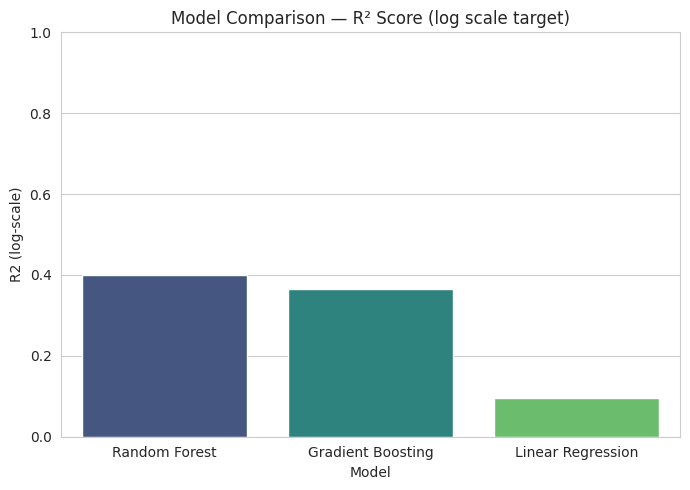

In [19]:
plt.figure(figsize=(7,5))
sns.barplot(data=results_df, x='Model', y='R2 (log-scale)', palette='viridis')
plt.title('Model Comparison — R² Score (log scale target)')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=110)
plt.show()


## 8. Best Model & Feature Importance

Based on the comparison above, the best performing model is selected. We inspect which features drive its predictions the most.


In [20]:
best_model_name = results_df.iloc[0]['Model']
print("Best model:", best_model_name)

best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[best_model_name])])
best_pipe.fit(X_train, y_train)


Best model: Random Forest


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

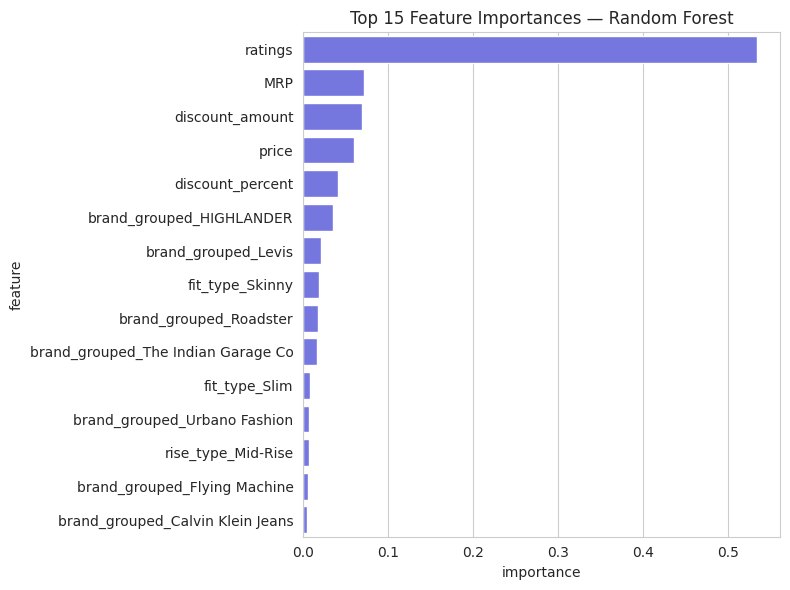

In [21]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    ohe = best_pipe.named_steps['preprocessor'].named_transformers_['cat']
    cat_feature_names = list(ohe.get_feature_names_out(features_cat))
    all_feature_names = features_num + cat_feature_names

    importances = best_pipe.named_steps['model'].feature_importances_
    fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8,6))
    sns.barplot(data=fi_df, x='importance', y='feature', color='#6366F1')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=110)
    plt.show()
else:
    print("Linear Regression selected — inspect model.coef_ for feature weights instead.")


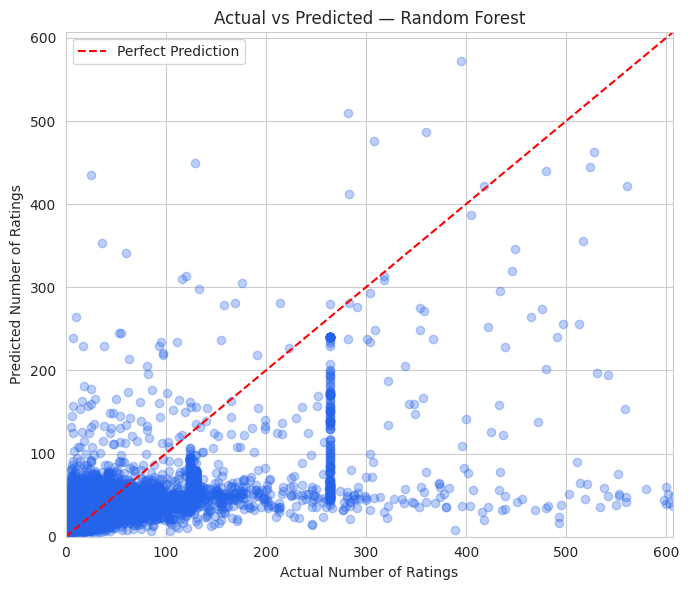

In [22]:
# Actual vs Predicted plot on the test set (original scale)
preds_log = best_pipe.predict(X_test)
y_test_orig = np.expm1(y_test)
preds_orig = np.expm1(preds_log)

plt.figure(figsize=(7,6))
plt.scatter(y_test_orig, preds_orig, alpha=0.3, color='#2563EB')
max_val = max(y_test_orig.max(), preds_orig.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlim(0, y_test_orig.quantile(0.98))
plt.ylim(0, y_test_orig.quantile(0.98))
plt.xlabel('Actual Number of Ratings')
plt.ylabel('Predicted Number of Ratings')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png', dpi=110)
plt.show()


## 9. Predicting Sales for a New Product

Below is a reusable function to predict the sales proxy (`number_of_ratings`) for a brand-new product listing, given its price, MRP, discount, rating and attributes.


In [23]:
def predict_sales(brand, price, mrp, discount_percent, rating, fit_type='Slim', rise_type='Mid-Rise'):
    brand_g = brand if brand in top_brands else 'Other'
    sample = pd.DataFrame([{
        'price': price,
        'MRP': mrp,
        'discount_percent': discount_percent,
        'discount_amount': mrp - price,
        'ratings': rating,
        'brand_grouped': brand_g,
        'fit_type': fit_type,
        'rise_type': rise_type
    }])
    pred_log = best_pipe.predict(sample)[0]
    return round(np.expm1(pred_log))

# Example usage
example_prediction = predict_sales(brand='Levis', price=1499, mrp=2999, discount_percent=0.5, rating=4.2, fit_type='Slim', rise_type='Mid-Rise')
print(f"Predicted number of ratings (sales proxy) for this product: {example_prediction}")


Predicted number of ratings (sales proxy) for this product: 303


## 10. Conclusion

- We cleaned a real-world, web-scraped Myntra product dataset (removing duplicates and fixing an inconsistent discount-percentage scale).
- We engineered meaningful features (`fit_type`, `rise_type`, `discount_amount`) from raw text descriptions.
- We used `number_of_ratings` as a practical **proxy for product sales/demand**, since true unit-sales figures are not publicly available.
- We compared Linear Regression, Random Forest and Gradient Boosting models; the **tree-based ensemble models outperformed the linear baseline**, indicating non-linear relationships between price, discount, brand and demand.
- `price`, `discount_percent`/`discount_amount` and `brand` consistently emerged as the most influential features driving predicted demand.

### Limitations & Future Work
- `number_of_ratings` is a reasonable but imperfect proxy for actual sales — not every buyer leaves a rating.
- The dataset is limited to the men's jeans/pants category; extending it to other categories would improve generalisability.
- Additional features (product images, textual reviews via NLP, seasonality, stock availability) could further improve prediction accuracy.
- Hyperparameter tuning (e.g. via `GridSearchCV`) and cross-validation could be used to squeeze out further performance.
